`03_split_ds_yolo.iptnb` se realizará la creación del dataset de YOLO y separación en train, validación y test.

# Importaciones

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2 
import os
from dataset.scanner import scan_raw_dataset
from dataset.analyzer import generate_dataset_summary, parse_annotations
from dataset.splitter import (
    get_processed_videos_dict,
    filter_processed_data,
    get_min_frames_count,
    generate_balanced_kfold_yolo,
    generate_random_kfold_yolo,
    get_experiment_splits_df
)
from utils.file_utils import load_gt

# Estudio del dataset

A continuación se retoma el estudio del dataset, que ayudará a realizar la toma de decisiones

In [2]:
PROJECT_ROOT = Path().resolve().parent
CONFIG_PATH = PROJECT_ROOT / 'paths.yaml'
ds_info = scan_raw_dataset(CONFIG_PATH)
df_summary = generate_dataset_summary(ds_info)

Visualizamos el resumen de los videos

In [3]:
df_videos_tech = df_summary.groupby('video_name')[['width', 'height', 'fps', 'total_frames']].first()
df_videos_tech['duration_sec'] = df_videos_tech['total_frames'] / df_videos_tech['fps']
display(df_videos_tech)

,width,height,fps,total_frames,duration_sec
video_name,,,,,
horse_1,2560,1440,30.0,284,9.466667
horse_2,2560,1440,30.0,310,10.333333
horse_3,2560,1440,30.0,1434,47.800000
horse_4,2560,1440,30.0,206,6.866667
horse_5,2560,1440,30.0,325,10.833333
horse_6,2560,1440,30.0,315,10.500000
horse_7,2560,1440,30.0,1315,43.833333
penguin_1,2560,1440,30.0,314,10.466667
penguin_2,2560,1440,30.0,325,10.833333


Se observa primero anomalias de resolución en uno de los vídeos de los pinguinos, por tanto se procede a visualizar dos frames de cada uno de los vídeos de los pinguinos para observar el porque

In [4]:
def plot_class_samples(scanned_data, class_name, frame_id=100):
    """
    Plots a grid showing one specific frame from every video of a given class.
    Includes the video name and its resolution in the title.
    """
    # Filtrar solo los vídeos de la clase especificada
    videos_list = scanned_data['data'].get(class_name, [])
    n_videos = len(videos_list)
    
    if n_videos == 0:
        print(f"No hay videos para la clase {class_name}")
        return

    # Calcular filas y columnas para el subplot (ej. 2 filas de 3 columnas para 6 vídeos)
    cols = 3
    rows = (n_videos + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), dpi=100)
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i, item in enumerate(videos_list):
        video_path = str(item['video'])
        
        cap = cv2.VideoCapture(video_path)
        if cap.isOpened():
            # Extraer resolución
            w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            
            # Leer el frame específico
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
            ret, frame = cap.read()
            
            if ret:
                # Convertir a RGB para Matplotlib
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                axes[i].imshow(frame_rgb)
                # Título con nombre del vídeo y resolución
                axes[i].set_title(f"{item['video'].stem}\nResolución: {w}x{h}", fontsize=12)
            else:
                axes[i].set_title(f"Error reading frame\n{item['video'].stem}")
                
            cap.release()
            
        axes[i].axis('off')

    # Ocultar los ejes sobrantes si n_videos no es múltiplo de cols
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

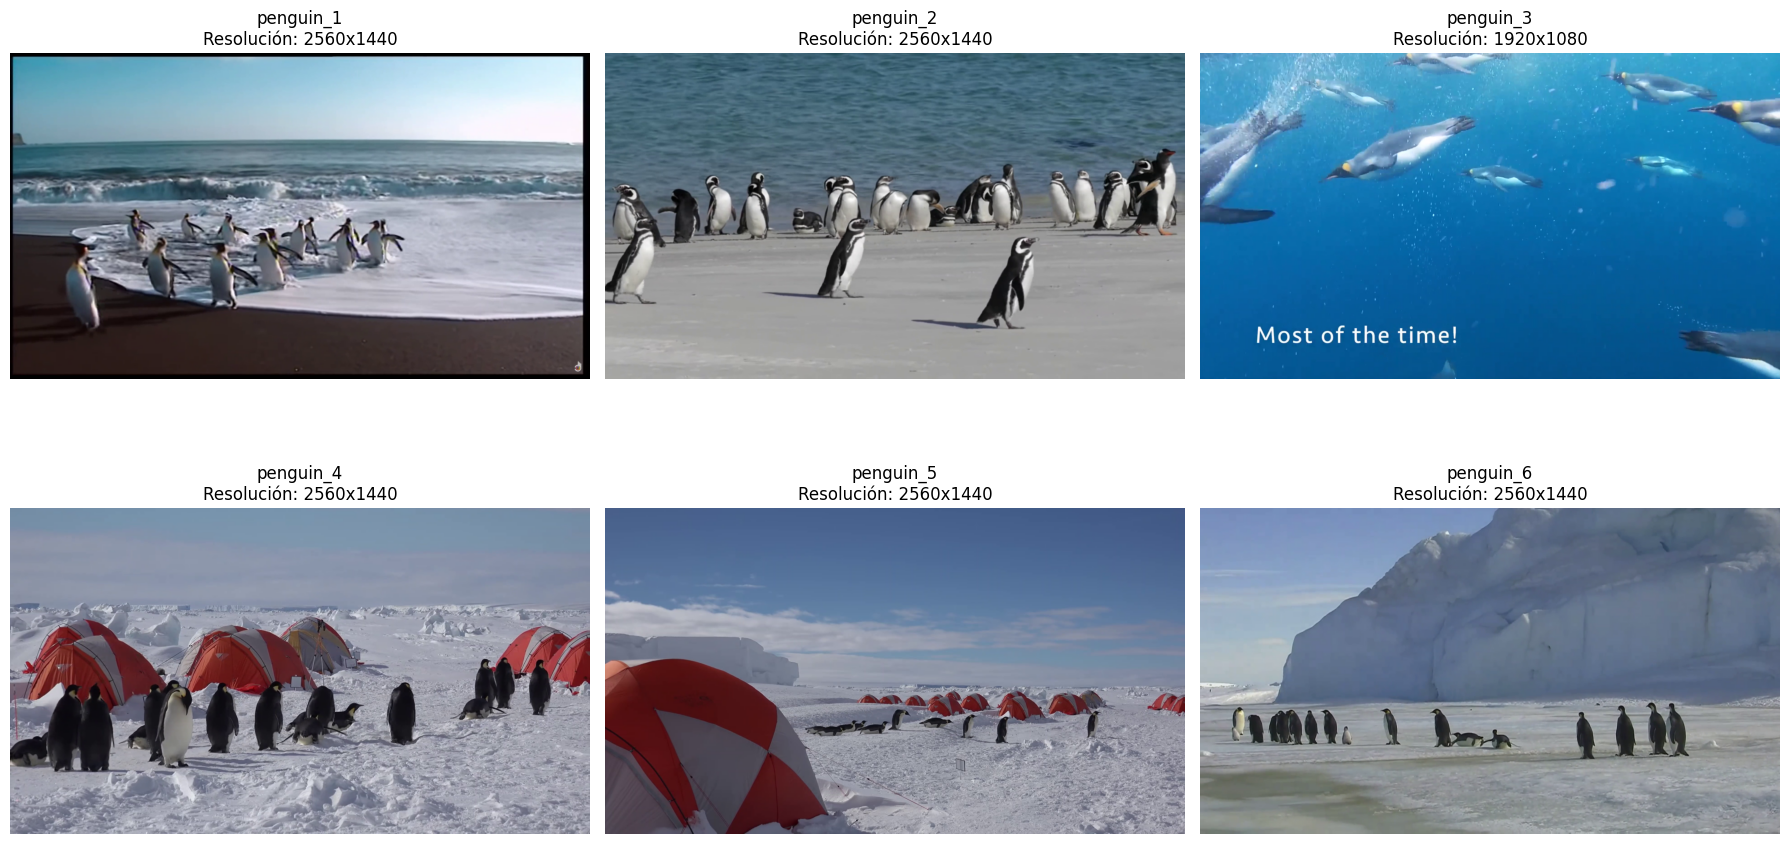

In [5]:
plot_class_samples(ds_info, class_name='penguin', frame_id=100)

# Separación train/val/test

Para garantizar un entrenamiento y evaluación rigurosos de los modelos, la división del dataset se rige por los siguientes principios metodológicos:

* El vídeo como "unidad indivisible": Para evitar la fuga de datos (data leakage), un vídeo completo se considera un único dato. Jamás se mezclan frames de un mismo vídeo entre Entrenamiento y Validación.
* Aislamiento de anomalías: Se descarta el vídeo penguin_3 debido a que su entorno subacuático y su resolución atípica (1920x1080) podrían distorsionar el entrenamiento base.
* Conjunto de Test fijo: Para que la comparativa final sea justa y científica, se reserva estrictamente un vídeo de cada clase como conjunto de Test. Este conjunto será idéntico para todos los experimentos.

Escenarios de Experimentación (Train / Val).

Con los vídeos restantes, y utilizando Validación Cruzada (K-Fold), generaremos varios conjuntos de datos para analizar cómo afecta el balanceo al modelo YOLO:

* **Escenario 1** (Balance Total): Separación equitativa en clases (mismos vídeos) y en número de frames. Se aplica submuestreo para extraer la misma cantidad de imágenes de cada vídeo.
* **Escenario 2** (Desbalance Temporal): Separación equitativa por clases, pero usando todos los frames. Esto nos permitirá evaluar si el modelo se sobreajusta a los vídeos más largos.
* **Escenario 3** (Desbalance Total): Separación aleatoria, sin forzar balanceo de clases ni frames. Demostrará empíricamente cómo la falta de estratificación perjudica al modelo en las clases minoritarias

In [6]:
processed_path = ds_info['processed_path']
class_names = list(ds_info['classes'].keys())
processed_pool = get_processed_videos_dict(processed_path, class_names)

In [12]:
anomalies = ["penguin_3"]
filtered_dict, _ = filter_processed_data(processed_pool,  anomalies)

In [13]:
min_frames_dataset = get_min_frames_count(filtered_dict)
print(f"Vídeos tras filtrado: {sum(len(v) for v in filtered_dict.values())}")
print(f"Mínimo de frames detectado para balanceo: {min_frames_dataset}")

Vídeos tras filtrado: 17
Mínimo de frames detectado para balanceo: 41


In [27]:
experiments_dir = processed_path / "experiments"
generate_balanced_kfold_yolo(
    data_dict=filtered_dict,
    output_path=experiments_dir,
    set_name="set1_balanced_subsampled",
    train_videos_per_class=3, 
    k_folds=5,
    subsample=True,
    class_names = class_names,
    target_frames=min_frames_dataset 
)

✅ Balanced YOLO configuration files generated successfully in: /root/MURIA/Object_Recognition/dataset/processed/experiments/set1_balanced_subsampled


In [28]:
generate_balanced_kfold_yolo(
    data_dict=filtered_dict,
    output_path=experiments_dir,
    set_name="set2_balanced_full",
    train_videos_per_class=3,
    k_folds=5,
    class_names=class_names,
    subsample=False
)

✅ Balanced YOLO configuration files generated successfully in: /root/MURIA/Object_Recognition/dataset/processed/experiments/set2_balanced_full


In [30]:
generate_random_kfold_yolo(
    data_dict=filtered_dict,
    output_path=experiments_dir,
    set_name="set3_random_full",
    k_folds=5,
    class_names=class_names,
    subsample=False 
)

✅ Random/Unbalanced YOLO configuration files generated successfully in: /root/MURIA/Object_Recognition/dataset/processed/experiments/set3_random_full


## Summary Folds

A continuación creamos una tabla para ver que videos aparecen en cada fold. Y también se crea el código latex para facilitar la implementación en el documento

In [31]:
df_escenario_1_2 = get_experiment_splits_df(
    filtered_dict, 
    k_folds=4, 
    train_videos_per_class=3, 
    is_random=False
)
print("--- Escenario 1 y 2: Balanceado ---")
display(df_escenario_1_2)
df_escenario_1_2.to_latex(
            caption="esc1_2",
            label="tab:esc1_2"
)

latex_code = df_escenario_1_2.to_latex(
    caption="Estrategia de división de videos para Escenarios 1 y 2",
    label="tab:esc1_2",
    index=False
)
os.makedirs('docs/latex', exist_ok=True)

file_path = 'docs/latex/esc1_2.tex'
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(latex_code)

print(f"✅ Archivo LaTeX guardado correctamente en: {file_path}")

--- Escenario 1 y 2: Balanceado ---


,video,Fold_1,Fold_2,Fold_3,Fold_4
0,horse_1,Train,Val,Val,Val
1,horse_2,Train,Train,Val,Val
2,horse_3,Train,Train,Train,Val
3,horse_4,Val,Train,Train,Train
4,horse_5,Val,Val,Train,Train
5,horse_6,Val,Val,Val,Train
6,horse_7,Test,Test,Test,Test
7,penguin_1,Train,Val,Train,Train
8,penguin_2,Train,Train,Val,Train
9,penguin_4,Train,Train,Train,Val


✅ Archivo LaTeX guardado correctamente en: docs/latex/esc1_2.tex


In [32]:
df_escenario_3 = get_experiment_splits_df(
    filtered_dict, 
    k_folds=4, 
    train_videos_per_class=None, # No se usa en random
    is_random=True
)

print("\n--- Escenario 3: Random ---")
display(df_escenario_3)

df_escenario_3.to_latex(
            caption="esc2",
            label="tab:esc2"
)

latex_code = df_escenario_3.to_latex(
    caption="Estrategia de división de videos para Escenarios 1 y 2",
    label="tab:esc3",
    index=False
)
os.makedirs('docs/latex', exist_ok=True)

file_path = 'docs/latex/esc3.tex'
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(latex_code)

print(f"✅ Archivo LaTeX guardado correctamente en: {file_path}")


--- Escenario 3: Random ---


,video,Fold_1,Fold_2,Fold_3,Fold_4
0,horse_1,Train,Train,Train,Val
1,horse_2,Train,Train,Train,Val
2,horse_3,Train,Train,Val,Train
3,horse_4,Train,Train,Train,Val
4,horse_5,Train,Train,Train,Val
5,horse_6,Train,Train,Val,Train
6,horse_7,Test,Test,Test,Test
7,penguin_1,Train,Val,Train,Train
8,penguin_2,Val,Train,Train,Train
9,penguin_4,Val,Train,Train,Train


✅ Archivo LaTeX guardado correctamente en: docs/latex/esc3.tex
